# Composite Overwrapped Pressure Vessel (COPV)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/shell/copv.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/shell/copv.ipynb)

A filament-wound pressure vessel modeled as a layered `Shell`: a metallic liner
overwrapped with helical carbon-fiber plies and loaded by internal pressure. One
octant of the vessel is meshed and closed with symmetry planes.

## Material and laminate

An isotropic aluminium liner combined with an orthotropic carbon/epoxy overwrap.
The liner is much thicker than the individual composite plies, which are wound in
a ±15° helical pattern. `Laminate.plot()` shows the resulting stacking sequence.

In [1]:
import torch

from torchfem import Laminate
from torchfem.data import get_data
from torchfem.io import import_mesh
from torchfem.materials import (
    IsotropicElasticityPlaneStress,
    OrthotropicElasticityPlaneStress,
)

torch.set_default_dtype(torch.float64)

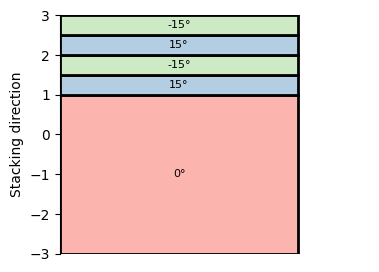

In [2]:
cfrp = OrthotropicElasticityPlaneStress(
    E_1=176800.0,
    E_2=10300.0,
    nu_12=0.23,
    G_12=4800.0,
    G_13=4800.0,
    G_23=3000.0,
    rho=1.6e-9,
)

alu = IsotropicElasticityPlaneStress(
    E=72000.0,
    nu=0.33,
    rho=2.7e-9,
)


p = torch.deg2rad(torch.tensor(15.0))
m = torch.deg2rad(torch.tensor(-15.0))
layup = Laminate(
    materials=[alu, cfrp, cfrp, cfrp, cfrp],
    thicknesses=[4.0, 0.5, 0.5, 0.5, 0.5],
    angles=[torch.tensor(0.0), p, m, p, m],
)

layup.plot()

## Model setup

One octant of the vessel — a dome-capped half cylinder — is imported from a VTU
file and assigned the laminate. The default `orientation` (global x, the vessel
axis) projects onto each element as the meridional direction, so ply angles are
measured from the meridian.

In [3]:
# Import mesh
path = get_data("copv.vtu")
copv = import_mesh(path, layup)
nodes = copv.nodes
elements = copv.elements

# Show mesh
copv.plot()

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

## Boundary conditions and loading

Three symmetry planes close the octant: the cut at `x = 0` and the `y = 0` and
`z = 0` planes. Each plane fixes the out-of-plane translation and the two
in-plane rotations. Internal pressure is applied as outward nodal forces, with
every element contributing `p · area / 3` along its outward normal to each of its
three nodes.

In [4]:
# Symmetry at x
x_symm = nodes[:, 0] > -0.1
copv.constraints[x_symm, 0] = True
copv.constraints[x_symm, 4] = True
copv.constraints[x_symm, 5] = True
# Symmetry at y
y_symm = nodes[:, 1] < 0.1
copv.constraints[y_symm, 1] = True
copv.constraints[y_symm, 3] = True
copv.constraints[y_symm, 5] = True
# Symmetry at z
z_symm = nodes[:, 2] < 0.1
copv.constraints[z_symm, 2] = True
copv.constraints[z_symm, 3] = True
copv.constraints[z_symm, 4] = True

# Internal pressure as outward nodal forces: f = p * area / 3 along the normal
pressure = 10.0  # internal gauge pressure [MPa]
v0, v1, v2 = nodes[elements[:, 0]], nodes[elements[:, 1]], nodes[elements[:, 2]]
normal = torch.linalg.cross(v1 - v0, v2 - v0)
area = 0.5 * torch.linalg.norm(normal, dim=1)
normal = torch.nn.functional.normalize(normal, dim=1)

nodal = torch.zeros_like(nodes)
for a in range(3):
    nodal.index_add_(0, elements[:, a], (pressure * area / 3.0)[:, None] * normal)
copv.forces[:, 0:3] = nodal

## Solve

A single linear solve, since all plies are linear elastic. 

In [5]:
u, f, sigma, _, _ = copv.solve(aggregate_integration_points=False)

## Results

The nodal radial expansion is recovered by projecting the displacement onto the radial 
direction.

In [6]:
radius = torch.sqrt(nodes[:, 1] ** 2 + nodes[:, 2] ** 2)
u_radial = (u[:, 1] * nodes[:, 1] + u[:, 2] * nodes[:, 2]) / radius.clamp(min=1e-6)

copv.plot(u=10.0 * u[:, :3], node_property={"Radial expansion [mm]": u_radial})

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

## Per-ply stresses

In the element frame the in-plane axes are meridional (`x'`, the winding
reference) and hoop (`y'`). The aluminium liner carries most of the hoop load,
while the helical CFRP plies carry the meridional/axial load.

In [7]:
n_layers = copv.section.n_layers
n_simpson = copv.section.n_simpson

meridional = sigma[:, :, 0, 0].reshape(n_layers, n_simpson, -1)
hoop = sigma[:, :, 1, 1].reshape(n_layers, n_simpson, -1)
labels = ["Al liner", "CFRP +15°", "CFRP -15°", "CFRP +15°", "CFRP -15°"]
for k, label in enumerate(labels):
    print(
        f"{label:10s}: Max. meridional : {meridional[k].max():6.2f} MPa,"
        f" Max. hoop : {hoop[k].max():6.2f} MPa"
    )

Al liner  : Max. meridional : 122.23 MPa, Max. hoop : 241.08 MPa
CFRP +15° : Max. meridional : 192.07 MPa, Max. hoop :  36.06 MPa
CFRP -15° : Max. meridional : 191.28 MPa, Max. hoop :  36.53 MPa
CFRP +15° : Max. meridional : 193.49 MPa, Max. hoop :  37.31 MPa
CFRP -15° : Max. meridional : 191.93 MPa, Max. hoop :  37.92 MPa
